# Characteristics of Times Series

Here, we'll study some properties of returns series for asset AAPL, GLD, INTC, SPY

In [1]:
INDEX = ["AAPL", "GLD", "INTC", "SPY"]

from fts_tool.config import PRICES_DATA_SOURCE
from fts_tool.ingestion import YahooFinanceIngestor
import pandas as pd
import numpy as np

prices_df = {}

for ticker in INDEX:
    yf_ingestor = YahooFinanceIngestor(ticker=ticker, start_date="2018-01-01", end_date="2023-01-01", interval="1d")
    data = yf_ingestor.fetch_data()
    processed_data = yf_ingestor.process_data(data)

    yf_ingestor.store_data(processed_data)

    prices_df[ticker] = processed_data

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [2]:
AAPL_prices = prices_df["AAPL"].Close.sort_index()

In [3]:
from fts_tool.analysis import FTSAnalyzer

ts_analyzer = FTSAnalyzer(AAPL_prices)

ts_analyzer.define_ts(ts_analyzer.returns)

C:\Users\chris\AppData\Roaming\Python\Python312\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.stats import gaussian_kde


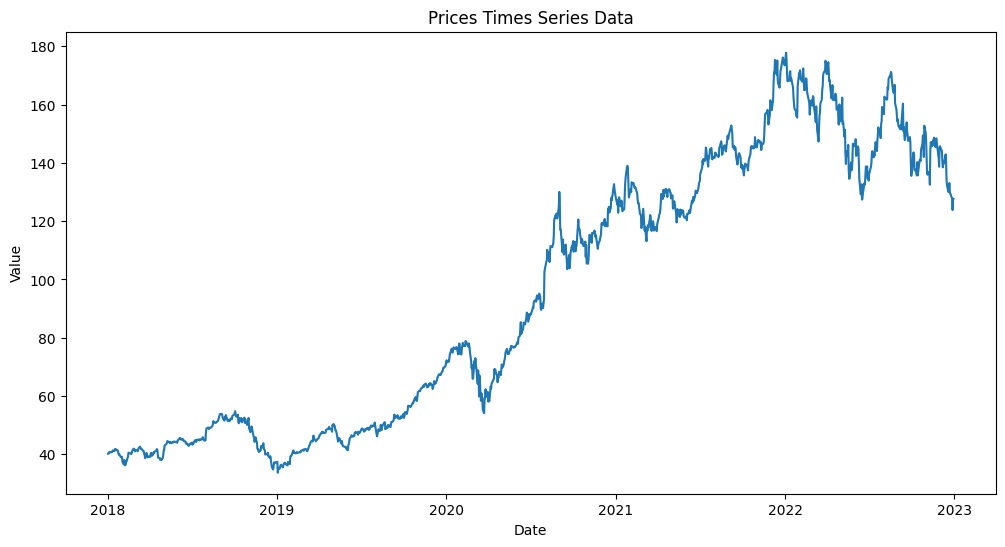

In [4]:
ts_analyzer.prices_plot()

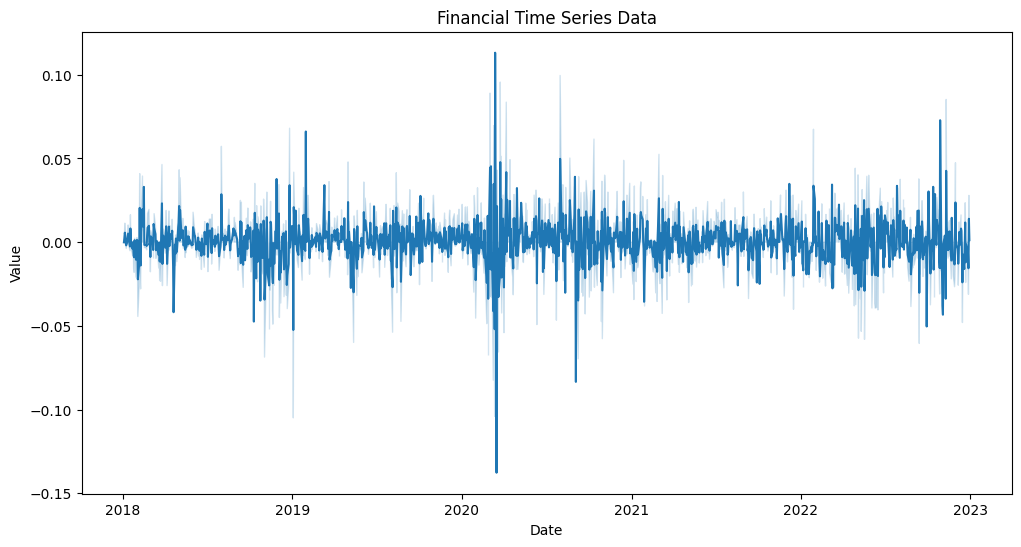

Summary of Financial Time Series Data:
Mean: 0.0004925903532395447
Volatility: 0.015466288468492214
Excess Kurtosis: 8.157305991430215
Skewness: -0.2340174565587329


In [8]:
# Simple return analysis

ts_analyzer.define_ts(ts_analyzer.log_returns)
ts_analyzer.plot_ts()
ts_analyzer.print_summary()

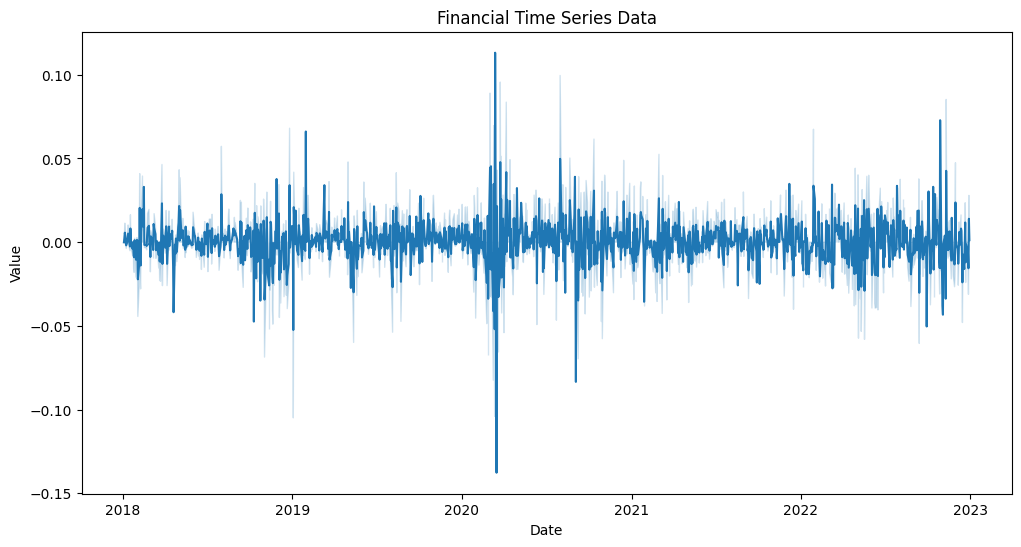

Summary of Financial Time Series Data:
Mean: 0.0004925903532395447
Volatility: 0.015466288468492214
Excess Kurtosis: 8.157305991430215
Skewness: -0.2340174565587329


In [7]:
# Log return analysis

ts_analyzer.define_ts(ts_analyzer.log_returns)
ts_analyzer.plot_ts()
ts_analyzer.print_summary()